In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
    Created on Thu Jul 18 2025
    
    @author: Yaning
"""

import os
import torch
import pyro
from pyro.optim import Adam
import pyro.distributions as dist
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pickle
import seaborn as sns
import pickle
from pyro.infer import SVI, Trace_ELBO
import re
import pandas as pd

/home/yaning/Documents/python_envs/spike/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
with open('/home/yaning/Documents/Discounting/results/array_cafe_gamble.pkl', 'rb') as f:
    data = pickle.load(f)

In [4]:
data = data[0]

In [5]:
data = torch.tensor(data)

In [6]:
data = data.to(device)

In [7]:
data.shape

torch.Size([30, 170, 8])

In [19]:
data = data.reshape(60,170,8)

In [8]:
def model(data):
    num_params = 3
    num_agents = data.shape[0]
    num_trials = data.shape[1]
    # define hyper priors over model parameters
    # prior over sigma of a Gaussian is a Gamma distribution
    a = pyro.param('a', torch.ones(num_params, device=device), constraint=dist.constraints.positive)
    lam = pyro.param('lam', torch.ones(num_params, device=device), constraint=dist.constraints.positive)
    tau = pyro.sample('tau', dist.Gamma(a, a/lam).to_event(1)) # mean = a / (a/lam) = lam

    sig = pyro.deterministic('sig', 1/torch.sqrt(tau)) # Gauss sigma

    # each model parameter has a hyperprior defining group level mean
    # in the form of a Normal distribution
    m = pyro.param('m', torch.zeros(num_params, device=device))
    s = pyro.param('s', torch.ones(num_params, device=device), constraint=dist.constraints.positive)
    mu = pyro.sample('mu', dist.Normal(m, s*sig).to_event(1)) # Gauss mu, wieso s*sig?

    # in order to implement groups, where each subject is independent of the others, pyro uses so-called plates.
    # you embed what should be done for each subject into the "with pyro.plate" context
    # the plate vectorizes subjects and adds an additional dimension onto all arrays/tensors
    # i.e. p1 below will have the length num_agents
    with pyro.plate('ag_idx', num_agents):
        # draw parameters from Normal and transform (for numeric trick reasons)
        # base_dist = dist.Normal(0., 1.).expand_by([num_params]).to_event(1)
        base_dist = dist.Normal(torch.zeros(num_params, device=device), torch.ones(num_params, device=device)).to_event(1)
        # Transform via the pointwise affine mapping y = loc + scale*x (-> Neal's funnel)
        transform = dist.transforms.AffineTransform(mu, sig)

        locs = pyro.sample('locs', dist.TransformedDistribution(base_dist, [transform]))
        # print(locs.shape)


    with pyro.plate('data', num_agents*num_trials):
        sigma_rate = torch.exp(locs[:,0]).unsqueeze(-1).expand(-1, num_trials)
        # a = torch.exp(locs[:,1]).unsqueeze(-1).expand(-1, num_trials)
        b = torch.exp(locs[:,1]).unsqueeze(-1).expand(-1, num_trials)
        # tan_a = torch.exp(locs[:,1]).unsqueeze(-1).expand(-1, num_trials)
        # tan_b = locs[:,2].unsqueeze(-1).expand(-1, num_trials)
        beta = torch.exp(locs[:,2]).unsqueeze(-1).expand(-1, num_trials)

        sigma_combine = sigma_rate/(1+b*torch.exp(-data[:,:,2]))
        # sigma_combine = sigma_rate
        # sigma_combine = sigma_rate*torch.log(data[:,:,2]*ln_a + 1)
        # sigma_combine = sigma_rate*(torch.tanh(tan_a*data[:,:,2] + tan_b) + 1)

        e_mean = (data[:,:,3])/(1 + sigma_combine**2)

        # e_mean = (data[:,:,3])/(sigma_combine + 1)
        sum = e_mean + torch.tensor(20., device=device)
        p_ll = e_mean/sum
        p_ss = torch.tensor(20.)/sum
        p = p_ll**beta/(p_ll**beta + p_ss**beta)

        # softmax_args = torch.stack([beta*e_mean/sum, beta*torch.tensor(20., device=device)/sum])
        # p = torch.softmax(softmax_args, dim = 0)[0]

    pyro.sample("obs", dist.Bernoulli(probs = p).to_event(2), obs=data[:,:,4])

    # return locs

In [9]:
def guide(data):
    num_params = 3
    num_agents = data.shape[0]
    # biject_to(constraint) looks up a bijective Transform from constraints.real 
    # to the given constraint. The returned transform is guaranteed to have 
    # .bijective = True and should implement .log_abs_det_jacobian().
    trns = torch.distributions.biject_to(dist.constraints.positive)

    # define mean vector and covariance matrix of multivariate normal
    m_hyp = pyro.param('m_hyp', torch.zeros(2*num_params, device=data.device))
    st_hyp = pyro.param('scale_tril_hyp',
                    torch.eye(2*num_params, device=data.device),
                    constraint=dist.constraints.lower_cholesky)

    # set hyperprior to be multivariate normal
    # scale_tril (Tensor) – lower-triangular factor of covariance, with positive-valued diagonal
    hyp = pyro.sample('hyp',
                    dist.MultivariateNormal(m_hyp, scale_tril=st_hyp),
                    infer={'is_auxiliary': True})

    # mu & tau unconstrained
    unc_mu = hyp[..., :num_params]
    unc_tau = hyp[..., num_params:]

    # constrained tau, shape num_params, or num_particles, 1, num_params
    c_tau = trns(unc_tau)

    # ld = log_density
    # log_abs_det_jacobian(x, y) computes derivative |dy/dx|
    ld_tau = -trns.inv.log_abs_det_jacobian(c_tau, unc_tau)
    
    # sum_rightmost(x, dim)
    # sum out ``dim`` many rightmost dimensions of a given tensor.
    # ld_tau.shape is num_params, or num_particles, 1, num_params before sum_rightmost
    ld_tau = dist.util.sum_rightmost(ld_tau, ld_tau.dim() - c_tau.dim() + 1)

    # some numerics tricks
    mu = pyro.sample("mu", dist.Delta(unc_mu, event_dim=1))
    # c_tau shape: num_params, or num_particles, 1, num_params
    # ld_tau shape: [] or num_particles, 1,
    tau = pyro.sample("tau", dist.Delta(c_tau, log_density=ld_tau, event_dim=1))

    m_locs = pyro.param('m_locs', torch.zeros(num_agents, num_params, device=data.device))
    st_locs = pyro.param('scale_tril_locs',
                    torch.eye(num_params, device=data.device).repeat(num_agents, 1, 1),
                    constraint=dist.constraints.lower_cholesky)
    
    with pyro.plate('ag_idx', num_agents):
        locs = pyro.sample("locs", dist.MultivariateNormal(m_locs, scale_tril=st_locs))

    return {'tau': tau, 'mu': mu, 'locs': locs, 'm_locs': m_locs, 'st_locs': st_locs}

Mean ELBO 1369.30: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:31<00:00, 156.46it/s]


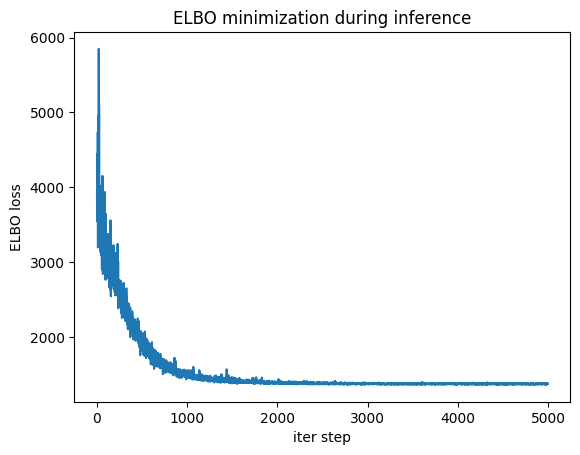

In [10]:
# this is for running the notebook in our testing framework
smoke_test = ('CI' in os.environ)
# the step was 2000
n_steps = 2 if smoke_test else 5000

# assert pyro.__version__.startswith('1.8.6')

# clear the param store in case we're in a REPL
pyro.clear_param_store()# setup the optimizer
# the learning rate was 0.0005 , "betas": (0.90, 0.999)
# tried "n_par":15 in adam params but it does not have this argument
adam_params = {"lr": 0.01}
optimizer = Adam(adam_params)
# setup the inference algorithm
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())
# svi = SVI(model_gamma, guide_gamma, optimizer, loss=Trace_ELBO())

loss = []
pbar = tqdm(range(n_steps), position = 0)
# do gradient steps
for step in pbar:
    loss.append(torch.tensor(svi.step(data)))
    pbar.set_description("Mean ELBO %6.2f" % torch.tensor(loss[-20:]).mean())
    # for name, value in pyro.get_param_store().items():
    #     print(name, pyro.param(name))
    if torch.isnan(loss[-1]):
	    break

plt.figure()
plt.plot(loss)
plt.xlabel("iter step")
plt.ylabel("ELBO loss")
plt.title("ELBO minimization during inference")
plt.show()

In [12]:
for i in loss:
    print(i.numpy())

8074.6655
7325.2373
7209.6987
7186.7974
8527.801
7075.7583
7279.7935
7136.6665
7232.856
7724.99
6987.4893
7129.4536
7373.09
7146.6416
6849.8047
6599.68
7819.052
7437.759
6705.1577
7293.949
6903.5874
6761.1123
7037.6123
6557.456
6849.0317
7413.823
6788.9126
6927.873
6968.686
6907.932
6949.0347
7032.237
6793.055
6820.4023
7319.7666
6734.1704
7082.92
6569.5005
7462.258
6832.195
6464.3145
6860.9717
6711.299
6664.904
6576.62
6876.357
6864.787
6386.6187
7002.647
6917.2817
6314.555
6251.6733
6712.598
6506.365
6359.4375
6585.68
6582.8354
6464.6704
6549.946
6726.7163
6445.9175
6798.836
6266.5596
6715.46
6591.183
6647.773
6328.38
6784.516
6702.0073
6831.6313
6297.6133
6100.6655
6571.7153
6317.9473
6393.4604
6213.111
6359.0264
6599.0317
6800.0005
6426.078
6217.157
6351.09
6184.328
6275.5874
6391.806
6497.5815
6212.2393
6340.794
6155.0894
6484.695
6460.428
6492.9727
6469.4033
6104.6973
6321.5435
6293.585
6858.736
6274.014
6302.856
6189.891
6387.7676
6217.963
6487.3433
6403.134
6248.2266
6027.892
6

In [12]:
pos_dict = {}
for name, value in pyro.get_param_store().items():
    pos_dict[name] = value

# change the dictionary to numpy instead of tensor
# because somehow the tensor cannot be save with pickle
numpy_dict = {key: value.detach().cpu().numpy() for key, value in pos_dict.items()}

In [24]:
#no future
numpy_dict["m"]

array([0.98587555, 1.7127005 , 2.3634577 ], dtype=float32)

In [ ]:
#future
numpy_dict["m"]

array([ 0.1338371, -1.2088407,  1.0144122,  3.1470098], dtype=float32)

In [120]:
df_indiv = pd.DataFrame(numpy_dict["m_locs"], columns=['sigma_rate', 'arctan_a', 'arctan_b', 'beta'])

In [121]:
df_mean = pd.DataFrame(numpy_dict["m"].reshape(1,4), columns=['sigma_rate', 'arctan_a', 'arctan_b', 'beta'])

In [122]:
df_indiv.to_csv("/home/yaning/Documents/Discounting/paper/results/arctan_indiv.csv", index=False)

In [123]:
df_mean.to_csv("/home/yaning/Documents/Discounting/paper/results/arctan_mean.csv", index=False)

In [13]:
# save the dictionary
with open('/home/yaning/Documents/Discounting/paper/results/three_param_cafe.pkl', 'wb') as f:
    pickle.dump(numpy_dict, f)

In [18]:
numpy_dict["m"]

array([0.8599359, 1.9331132, 2.3982897], dtype=float32)